# 🏥糖尿病早期遗传风险预测

##  实验目的
通过训练数据集构建糖尿病遗传风险预测模型，然后预测出测试数据集中个体是否患有糖尿病
## 数据集链接
[糖尿病遗传风险检测挑战赛数据集](http://challenge.xfyun.cn/topic/info?type=diabetes)

## 推荐阅读
⚡**[算法挑战赛-电信客户流失预测](https://www.heywhale.com/mw/project/62b13e5b655ee73e2dbe8971)**
💸**[Pandas+Plotly丨200+商品销售数据可视化](https://www.heywhale.com/mw/project/62a747c49e688fdaa3ecb0ef)**
💰️**[Tushare+Plotly丨实现可交互式的蜡烛K线图](https://www.heywhale.com/mw/project/62a0b6ec2d8168866e65a5a2)**
🎦**[视频评分预测挑战赛](https://www.heywhale.com/mw/project/629eddba2d8168866e53e714)**
🏠**[民宿价格预测](https://www.heywhale.com/mw-org/series_5ffbf4d2a96f9e0036c2bffb/project/627d0cbef9d3b38a5795107f)**
🕔**[sklearn机器学习](https://www.heywhale.com/mw/project/62276138b035430017a897e9?shareby=62275174de6e930017e265d5)**
🎯**[LightGBM算法学习](https://www.heywhale.com/mw/project/625d67d426bb0900178a185f?shareby=62275174de6e930017e265d5)**
💸**[化妆品电商平台数据可视化](https://www.heywhale.com/mw/project/624d788d37409c00175aea9a?shareby=62275174de6e930017e265d5)**
🏥**[上市公司风险预测](https://www.heywhale.com/mw/project/623aaf1edff0200017d8a2b8?shareby=62275174de6e930017e265d5)**
💰️**[Tushare金融量化](https://www.heywhale.com/mw/project/6238b327ae5cf10017ae4c6e?shareby=62275174de6e930017e265d5)**
***

## 数据集字段说明
编号：标识个体身份的数字；
性别：1表示男性，0表示女性；
出生年份：出生的年份；
体重指数（BMI）：体重除以身高的平方，单位kg/m2;
糖尿病家族史：标识糖尿病的遗传特性，记录家族里面患有糖尿病的家属，分成三种标识，分别是父母有一方患有糖尿病、叔叔或者姑姑有一方患有糖尿病、无记录；
舒张压：心脏舒张时，动脉血管弹性回缩时，产生的压力称为舒张压，单位mmHg；
口服耐糖量测试：诊断糖尿病的一种实验室检查方法。比赛数据采用120分钟耐糖测试后的血糖值，单位mmol/L；
胰岛素释放实验：空腹时定量口服葡萄糖刺激胰岛β细胞释放胰岛素。比赛数据采用服糖后120分钟的血浆胰岛素水平，单位pmol/L；
肱三头肌皮褶厚度：在右上臂后面肩峰与鹰嘴连线的重点处，夹取与上肢长轴平行的皮褶，纵向测量，单位cm；
患有糖尿病标识：数据标签，1表示患有糖尿病，0表示未患有糖尿病。
# 1.准备数据





In [25]:
# 导入需要的库
import pandas as pd
# 绘图库
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pickle
import datetime

In [26]:
# 定义一个前期理解数据的通用函数
def data_comprehension(path):
    # 读取文件，如果文件含有中文，要加encoding = 'gbk'
    df = pd.read_csv(path,encoding='gbk')
    # dataframe的维度
    print('数据集维度为:'f'{df.shape}')
    # 查看数据统计信息
    print('数据统计信息-------------------------------')
    print(df.describe())
    # 查看数据类型
    print('数据类型-----------------------------------')
    print(df.info())
    # 查看数据是否有重复值
    print('数据重复值---------------------------------')
    print('数据集的重复值为:'f'{df.duplicated().sum()}')
    # 查看数据是否有缺失值
    print('数据缺失值---------------------------------')
    print(df.isnull().sum())
    # 查看数据集的前五行
    print(df.head())

In [27]:
# 保存数据的函数
def save_variable(v,filename):
    f=open(filename,'wb')
    pickle.dump(v,f)
    f.close()
    return filename

# 加载数据的函数
def load_variavle(filename):
   f=open(filename,'rb')
   r=pickle.load(f)
   f.close()
   return r

## 1.1训练集

In [28]:
# 训练集路径
train_path = r'比赛训练集.csv'
data_comprehension(train_path)

数据集维度为:(5070, 10)
数据统计信息-------------------------------
                编号           性别         出生年份         体重指数          舒张压  \
count  5070.000000  5070.000000  5070.000000  5070.000000  4823.000000   
mean   2535.500000     0.456805  1986.869231    37.986785    89.423595   
std    1463.727263     0.498180     8.919737    11.447095     9.266992   
min       1.000000     0.000000  1943.000000     0.000000    30.000000   
25%    1268.250000     0.000000  1980.000000    28.400000    85.000000   
50%    2535.500000     0.000000  1987.000000    36.550000    89.000000   
75%    3802.750000     1.000000  1995.000000    47.600000    96.000000   
max    5070.000000     1.000000  2009.000000    65.900000   126.000000   

           口服耐糖量测试      胰岛素释放实验     肱三头肌皮褶厚度      患有糖尿病标识  
count  5070.000000  5070.000000  5070.000000  5070.000000  
mean      5.612839     4.114321     6.994371     0.381854  
std       2.257649     8.726001    13.651442     0.485889  
min      -1.000000     0.000000     0

## 1.2 测试集

In [29]:
# 测试集路径
test_path = r'比赛测试集.csv'
data_comprehension(test_path)

数据集维度为:(1000, 9)
数据统计信息-------------------------------
                编号           性别         出生年份         体重指数         舒张压  \
count  1000.000000  1000.000000  1000.000000  1000.000000  951.000000   
mean    500.500000     0.481000  1986.386000    39.439000   89.638275   
std     288.819436     0.499889     8.816163    11.284861    9.379124   
min       1.000000     0.000000  1958.000000     0.000000   28.000000   
25%     250.750000     0.000000  1979.000000    29.975000   85.000000   
50%     500.500000     0.000000  1987.000000    38.900000   89.000000   
75%     750.250000     1.000000  1994.000000    48.950000   96.000000   
max    1000.000000     1.000000  2003.000000    60.000000  112.000000   

           口服耐糖量测试      胰岛素释放实验     肱三头肌皮褶厚度  
count  1000.000000  1000.000000  1000.000000  
mean      5.872314     4.102700     7.064240  
std       1.930880     8.594005    13.900938  
min      -1.000000     0.000000     0.000000  
25%       4.516000     0.000000     0.000000  
50%  

训练集和测试集的“舒张压”特征存在缺失值，后续需要处理。

## 1.3 训练集标签统计

In [30]:
# 定义一个标签统计函数：路径，label名称
def label_count(train_path,label_name):
    df = pd.read_csv(train_path,encoding = 'gbk')
    print(df[label_name].value_counts())
    print(df[label_name].value_counts(normalize = True))
    # 保存标签
    labeldf = df[[label_name]]
    labeldf.to_csv(r'准备数据/label.csv',index = False,encoding = 'utf-8')
    print('成功~')

In [31]:
label_count(train_path,'患有糖尿病标识')

患有糖尿病标识
0    3134
1    1936
Name: count, dtype: int64
患有糖尿病标识
0    0.618146
1    0.381854
Name: proportion, dtype: float64
成功~


该数据集是一个不平衡数据集哦~
## 1.4 训练集和测试集合并

In [32]:
traindf = pd.read_csv(train_path,encoding = 'gbk')
testdf = pd.read_csv(test_path,encoding = 'gbk')
traindf = traindf.drop(['患有糖尿病标识'],axis = 1)
totaldf = pd.concat([traindf,testdf],axis = 0)
totaldf.to_csv(r'准备数据/totaldf.csv',index = False,encoding = 'utf-8')
totaldf.shape

(6070, 9)

## 1.5 分离出离散型特征和数值型特征

In [33]:
# 数值型特征和离散型特征分离函数
def feature_split(df):
    # 数值型特征
    num_var = df.select_dtypes(exclude = 'object')
    print(f'数值型维度{num_var.shape}')
    # 离散型特征
    object_var = df.select_dtypes(include = 'object')
    print(f'离散型维度{object_var.shape}')
    # 储存
    num_var.to_csv(r'准备数据/num_var.csv',index = False,encoding = 'utf-8')
    object_var.to_csv(r'准备数据/object_var.csv',index = False,encoding = 'utf-8')
    print('分离成功~')

In [34]:
feature_split(totaldf)

数值型维度(6070, 8)
离散型维度(6070, 1)
分离成功~


# 2.EDA分析
笔者原本是打算尝试用dataprep生成EDA分析报告，但是安装dataprep库会导致和鲸的kernel一直连不上，所以笔者还是跟往常一样一步步分析好了。
## 2.1标签与特征之间的交叉统计

In [35]:
# 读取训练集
traindf = pd.read_csv(train_path,encoding = 'gbk')
traindf.shape

(5070, 10)

In [36]:
%%time
for i in list(traindf.columns):
    if (i != '编号') & (i != '患有糖尿病标识'):
       fig0 = px.histogram(traindf,x = i,color = '患有糖尿病标识',marginal = 'box',barmode = 'overlay')
       fig0.write_html(f'EDA/{i}.html')

CPU times: total: 1.47 s
Wall time: 1.75 s


1.从性别交叉统计来分析，男女性患糖尿病人数是相当的，也可以通过概率进行分析；从下面概率统计不难看出，该数据集显示：男性患糖尿病的概率会大于女性；

In [37]:
girl = traindf[traindf['性别'] == 0]
girl['患有糖尿病标识'].value_counts(normalize = True)

患有糖尿病标识
0    0.632171
1    0.367829
Name: proportion, dtype: float64

In [38]:
boy = traindf[traindf['性别'] == 1]
boy['患有糖尿病标识'].value_counts(normalize = True)

患有糖尿病标识
0    0.601468
1    0.398532
Name: proportion, dtype: float64

2.该数据集的糖尿病患者主要集中在1972-2000年；
3.以下几个信息可以大致判定糖尿病：
* 体重指数在52-59.9kg/m2，
* 舒张压为102-110mmHg，
* 120分钟耐糖测试后的血糖值处于8.5-9.099mmol/L，
* 肱三头肌皮褶厚度位于39.5-45.49cm。

## 2.2 单变量分析
### 2.2.1 数值型特征
了解数值型数据的分布，同时观察可能需要过滤的离散值

In [39]:
num_var = pd.read_csv(r'准备数据/num_var.csv')
num_var.shape

(6070, 8)

In [40]:
# 定义频数分布直方图函数
# def hist_generate(df,feature_name,file_name):
    # fig = px.histogram(df,x = feature_name,marginal = 'box')
    # 生成html
    # fig.write_html(f'EDA/单变量/{file_name}/hist/{i}.html')
    # 也可以直接在notebook展示
    # fig.show()

# 定义频数分布直方图函数
def hist_generate(df,feature_name):
    fig = px.histogram(df,x = feature_name,marginal = 'box')
    # 生成html
    fig.write_html(f'hist/{i}.html')
    # 也可以直接在notebook展示
    # fig.show()

In [41]:
%%time
for i in list(num_var.columns):
    # hist_generate(num_var,i,'数值型特征')
    hist_generate(num_var,i)

print('绘图成功~')

绘图成功~
CPU times: total: 1.05 s
Wall time: 1.15 s


我们可以得到该数据集如下信息：
* 1.出生年份集中在1972-2000年；
* 2.口服耐糖量集中在3.1-8.699mmol/L，该特征存在**负数**需要处理；
* 3.舒张压集中在83-99mmHg；
* 4体重指数集中在20.5-59.4kg/m2这个区间；
* 5.该数据集女性会稍微比男生多一些。

有个别特征存在负数：
体重指数，肱三头肌皮褶厚度，胰岛素释放实验，口服耐糖量

### 2.2.2 离散型特征

In [42]:
object_var = pd.read_csv(r'准备数据/object_var.csv')
object_var.shape

(6070, 1)

In [43]:
fig1 = px.histogram(object_var,x = '糖尿病家族史',marginal = 'box')
fig1.show()

”无记录"的家族史占比是最多的；我们也发现，当中有两个选项是可以合并的：“叔叔或者姑姑有一方患有糖尿病” 和 “ 叔叔或姑姑有一方患有糖尿病”。

## 2.3 双变量分析
###  2.3.1合并的数据集 - 数值型特征
通过相关矩阵发现任何2个连续特征之间线性关系（相关），也可以确定研究我们独立预测因子之间的任何多重共线性

In [44]:
# 相关矩阵生成函数
def corr_generate(df):
    fig = px.imshow(df,text_auto=True,aspect="auto",color_continuous_scale='RdBu_r')
    fig.show()

In [45]:
totaldf = pd.read_csv(r'准备数据/totaldf.csv')
# total_corr = totaldf.corr()
numeric_columns = totaldf.select_dtypes(include=['int','float']).columns
total_corr = totaldf[numeric_columns].corr()
# 生成相关矩阵
corr_generate(total_corr)

不难看出，各特征之间的相关系数很小，不存在多重共线性

### 2.2.2 数值型特征与因变量之间的关系（训练集）

In [46]:
numeric_columns = traindf.select_dtypes(include=['int','float']).columns
train_corr = traindf[numeric_columns].corr()
# train_corr = traindf.corr()
# 通过生成相关矩阵，了解各特征与标签之间的相关性
corr_generate(train_corr)

从相关系数可以看出，肱三头肌皮褶厚度和体重指数与标签的相关度较高。
通过以上的EDA分析，我们已经对这份数据集有一定的了解了，接下来就是进行数据清洗啦~
# 3.数据清洗
## 3.1 处理缺失值
从前面的信息可以了解到，“舒张压”是存在缺失值的，我们需要进行填充处理，笔者在这里选择用“中位数”进行填充

In [47]:
totaldf['舒张压'] = totaldf['舒张压'].fillna(totaldf['舒张压'].median())
totaldf['舒张压'].isnull().sum()

0

## 3.2 处理负值
我们知道，体重指数，肱三头肌皮褶厚度，胰岛素释放实验，口服耐糖量这几个特征是存在负值的，需要我们进行处理

In [48]:
def negative_deal(df):
    q2 = df.quantile(0.5)
    for i in df:
        if i <=0 :
            df.replace(i,q2,inplace = True)
    return df

In [49]:
%%time
negative_list = ['体重指数','肱三头肌皮褶厚度','胰岛素释放实验','口服耐糖量测试']
for i in negative_list:
    totaldf[i] = negative_deal(totaldf[i])

CPU times: total: 2.59 s
Wall time: 2.67 s


In [50]:
%%time
# 存储处理后的数据
totaldf.to_csv(r'数据清洗/totaldf未处理离散值.csv',index = False,encoding ='utf-8')

CPU times: total: 46.9 ms
Wall time: 40.7 ms


In [51]:
totaldf = pd.read_csv(r'数据清洗/totaldf未处理离散值.csv')
totaldf.shape

(6070, 9)

# 4.特征工程
## 4.1分类类别中的直接类别处理
该数据集存在一个离散型特征：糖尿病家族史，我们首先需要将其转换为“数值”特征

In [52]:
feature_dict = {'无记录':0,'叔叔或者姑姑有一方患有糖尿病':1,'叔叔或姑姑有一方患有糖尿病':1,'父母有一方患有糖尿病':2}
totaldf['糖尿病家族史'] = totaldf['糖尿病家族史'].map(feature_dict)
totaldf.head()

,编号,性别,出生年份,体重指数,糖尿病家族史,舒张压,口服耐糖量测试,胰岛素释放实验,肱三头肌皮褶厚度
0,1,0,1996,30.1,0,106.0,3.818,7.89,0.0
1,2,0,1988,27.5,0,84.0,5.776,0.00,14.7
2,3,1,1988,36.5,0,85.0,7.131,0.00,40.1
3,4,1,1992,29.5,0,91.0,7.041,0.00,0.0
4,5,0,1998,42.0,1,89.0,7.134,0.00,0.0


## 4.2 特征创造
### 4.2.1 体质指数BMI
根据以下图片资料，我们可以根据现有的体重指数数据进行划分。

![Image Name](https://cdn.kesci.com/upload/image/refo107odc.png?imageView2/0/w/960/h/960)


In [53]:
# 定义BMI指数
def BMI(x):
    if x < 18.5:
        return 0
    elif 18.5 <= x <=23.9:
        return 1
    elif 24 <= x <= 27.9:
        return 2
    elif 28 <= x <= 29.9:
        return 3
    elif x >= 30:
        return 4

In [54]:
totaldf['体质指数-BMI'] = totaldf['体重指数'].map(BMI)
totaldf.head()

,编号,性别,出生年份,体重指数,糖尿病家族史,舒张压,口服耐糖量测试,胰岛素释放实验,肱三头肌皮褶厚度,体质指数-BMI
0,1,0,1996,30.1,0,106.0,3.818,7.89,0.0,4
1,2,0,1988,27.5,0,84.0,5.776,0.00,14.7,2
2,3,1,1988,36.5,0,85.0,7.131,0.00,40.1,4
3,4,1,1992,29.5,0,91.0,7.041,0.00,0.0,3
4,5,0,1998,42.0,1,89.0,7.134,0.00,0.0,4


### 4.2.2 ”年龄“特征

In [55]:
# 获取当前年份
in_those_year = datetime.datetime.now().year
totaldf['年龄'] = in_those_year - totaldf['出生年份']
totaldf.head()

,编号,性别,出生年份,体重指数,糖尿病家族史,舒张压,口服耐糖量测试,胰岛素释放实验,肱三头肌皮褶厚度,体质指数-BMI,年龄
0,1,0,1996,30.1,0,106.0,3.818,7.89,0.0,4,28
1,2,0,1988,27.5,0,84.0,5.776,0.00,14.7,2,36
2,3,1,1988,36.5,0,85.0,7.131,0.00,40.1,4,36
3,4,1,1992,29.5,0,91.0,7.041,0.00,0.0,3,32
4,5,0,1998,42.0,1,89.0,7.134,0.00,0.0,4,26


###  4.2.3 舒张压-DP
通过舒张压数据，我们根据下方图片提供的参考范围进行划分

![Image Name](https://cdn.kesci.com/upload/image/refoy76rp0.jpg?imageView2/0/w/960/h/960)


In [56]:
# 定义DP指数
def DP(x):
    if x < 80:
        return 0
    elif 80 <= x <= 89:
        return 1
    elif 90 <= x <= 99:
        return 2
    elif 100 <= x <= 109:
        return 3
    elif x >=110:
        return 4

In [57]:
totaldf['舒张压-DP'] = totaldf['舒张压'].map(DP)
totaldf.head()

,编号,性别,出生年份,体重指数,糖尿病家族史,舒张压,口服耐糖量测试,胰岛素释放实验,肱三头肌皮褶厚度,体质指数-BMI,年龄,舒张压-DP
0,1,0,1996,30.1,0,106.0,3.818,7.89,0.0,4,28,3
1,2,0,1988,27.5,0,84.0,5.776,0.00,14.7,2,36,1
2,3,1,1988,36.5,0,85.0,7.131,0.00,40.1,4,36,1
3,4,1,1992,29.5,0,91.0,7.041,0.00,0.0,3,32,2
4,5,0,1998,42.0,1,89.0,7.134,0.00,0.0,4,26,1


### 4.2.4 口服耐糖量测试-OGTT
同理，根据下方参考范围进行划分

![Image Name](https://cdn.kesci.com/upload/image/refpjnv5c.jpg?imageView2/0/w/960/h/960)


In [58]:
# 定义OGTT指数
def OGTT(x):
    if x <= 7.8:
        return 0
    else:
        return 1

In [59]:
totaldf['口服耐糖量测试-OGTT'] = totaldf['口服耐糖量测试'].map(OGTT)
totaldf.head()

,编号,性别,出生年份,体重指数,糖尿病家族史,舒张压,口服耐糖量测试,胰岛素释放实验,肱三头肌皮褶厚度,体质指数-BMI,年龄,舒张压-DP,口服耐糖量测试-OGTT
0,1,0,1996,30.1,0,106.0,3.818,7.89,0.0,4,28,3,0
1,2,0,1988,27.5,0,84.0,5.776,0.00,14.7,2,36,1,0
2,3,1,1988,36.5,0,85.0,7.131,0.00,40.1,4,36,1,0
3,4,1,1992,29.5,0,91.0,7.041,0.00,0.0,3,32,2,0
4,5,0,1998,42.0,1,89.0,7.134,0.00,0.0,4,26,1,0


In [60]:
%%time
totaldf.to_csv(r'特征工程/totaldf未处理离散值.csv',index = False,encoding = 'utf-8')

CPU times: total: 46.9 ms
Wall time: 51.8 ms


In [61]:
totaldf = pd.read_csv(r'特征工程/totaldf未处理离散值.csv')
totaldf.head()

,编号,性别,出生年份,体重指数,糖尿病家族史,舒张压,口服耐糖量测试,胰岛素释放实验,肱三头肌皮褶厚度,体质指数-BMI,年龄,舒张压-DP,口服耐糖量测试-OGTT
0,1,0,1996,30.1,0,106.0,3.818,7.89,0.0,4,28,3,0
1,2,0,1988,27.5,0,84.0,5.776,0.00,14.7,2,36,1,0
2,3,1,1988,36.5,0,85.0,7.131,0.00,40.1,4,36,1,0
3,4,1,1992,29.5,0,91.0,7.041,0.00,0.0,3,32,2,0
4,5,0,1998,42.0,1,89.0,7.134,0.00,0.0,4,26,1,0


In [62]:
totaldf.columns

Index(['编号', '性别', '出生年份', '体重指数', '糖尿病家族史', '舒张压', '口服耐糖量测试', '胰岛素释放实验',
       '肱三头肌皮褶厚度', '体质指数-BMI', '年龄', '舒张压-DP', '口服耐糖量测试-OGTT'],
      dtype='object')

# 5.建模
## 5.1 随机森林

In [63]:
# 忽略UndefinedMetricWarning警告
from sklearn.exceptions import UndefinedMetricWarning
import warnings
warnings.filterwarnings(action='ignore', category=UndefinedMetricWarning)
# 主要是为了导入GridSearchCV（开销太大了，超级耗时，想哭~）
import sklearn.model_selection as ms
# 导入文本报告
from sklearn.metrics import classification_report
# 导入随机森林分类器
from sklearn.ensemble import RandomForestClassifier
# 训练集和测试集分割
from sklearn.model_selection import train_test_split
# 用于保存和提取模型
import joblib

In [64]:
iddf = totaldf[['编号']]
iddf.to_csv(r'准备数据/编号.csv',index = False,encoding = 'utf-8')
totaldf = totaldf.drop(['编号'],axis = 1)
# 读取label文件
labeldf = pd.read_csv(r'准备数据/label.csv')
# 划分出训练集和测试集
train = totaldf.iloc[:5070,:]
test = totaldf.iloc[5070:,:]
x = train
y = labeldf['患有糖尿病标识']

In [65]:
%%time
print('正在处理中，请稍后...')
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25)
# 设置算法参数
deal_params = {'n_estimators':[ x for x in range(50,1050,10)]}
# 设置随机森林分类模型
RFC = RandomForestClassifier(criterion = 'gini',bootstrap=True,n_jobs = -1,random_state = 2022)
# 因为用的是分类器，所以这里的评估指标scoring要用分类任务的评价标准
# gridsearchcv优化
model = ms.GridSearchCV(RFC,deal_params,cv = 10,scoring='f1',error_score='raise')
# 随机搜索参数优化
# model = RandomizedSearchCV(RFC,deal_params,n_iter = 100,cv = 5,scoring = 'roc_auc',error_score='raise',random_state = 2022,n_jobs = -1)
model.fit(x_train,y_train)
print(f'当前最佳参数{model.best_params_}')
print(f'当前最佳分数{model.best_score_}')
print('处理成功~')

正在处理中，请稍后...


KeyboardInterrupt: 

In [ ]:
# 由于优化模型时间过长，所以保存过程变量，或机器学习的模型
filename = save_variable(x_train,'process_variable/x_train')
filename = save_variable(x_test,'process_variable/x_test')
filename = save_variable(y_train,'process_variable/y_train')
filename = save_variable(y_test,'process_variable/y_test')
filename = save_variable(deal_params,'process_variable/deal_params')
filename = save_variable(RFC,'process_variable/RFC')
filename = save_variable(model,'process_variable/model')

In [66]:
# 读取过程变量，不再运行机器学习算法
x_train = load_variavle('process_variable/x_train')
x_test = load_variavle('process_variable/x_test')
y_train = load_variavle('process_variable/y_train')
y_test = load_variavle('process_variable/y_test')
deal_params = load_variavle('process_variable/deal_params')
RFC = load_variavle('process_variable/RFC')
model = load_variavle('process_variable/model')

In [ ]:
%%time
print('正在处理中，请稍后...')
# 设置算法参数
deal_params = {'max_depth':[x for x in range(10,110,10)]}
# 设置随机森林分类模型
RFC = RandomForestClassifier(n_estimators = 470,criterion = 'gini',bootstrap=True,n_jobs = -1,random_state = 2022)
# 因为用的是分类器，所以这里的评估指标scoring要用分类任务的评价标准
# gridsearchcv优化
model = ms.GridSearchCV(RFC,deal_params,cv = 10,scoring='f1',error_score='raise')
# 随机搜索参数优化
# model = RandomizedSearchCV(RFC,deal_params,n_iter = 100,cv = 5,scoring = 'roc_auc',error_score='raise',random_state = 2022,n_jobs = -1)
model.fit(x_train,y_train)
print(f'当前最佳参数{model.best_params_}')
print(f'当前最佳分数{model.best_score_}')
print('处理成功~')

正在处理中，请稍后...
当前最佳参数{'max_depth': 20}
当前最佳分数0.9427323591113496
处理成功~
CPU times: total: 9min 58s
Wall time: 2min 47s


In [ ]:
# 保存
filename = save_variable(deal_params,'process_variable/deal_params2')
filename = save_variable(RFC,'process_variable/RFC2')
filename = save_variable(model,'process_variable/model2')

In [ ]:
# 读取
deal_params = load_variavle('process_variable/deal_params2')
RFC = load_variavle('process_variable/RFC2')
model = load_variavle('process_variable/model2')

In [ ]:
%%time
print('正在处理中，请稍后...')
# 设置算法参数
deal_params = {'min_samples_split':[x for x in range(2,11,1)]}
# 设置随机森林分类模型
RFC = RandomForestClassifier(n_estimators = 470,max_depth = 30,criterion = 'gini',bootstrap=True,n_jobs = -1,random_state = 2022)
# 因为用的是分类器，所以这里的评估指标scoring要用分类任务的评价标准
# gridsearchcv优化
model = ms.GridSearchCV(RFC,deal_params,cv = 10,scoring='f1',error_score='raise')
# 随机搜索参数优化
# model = RandomizedSearchCV(RFC,deal_params,n_iter = 100,cv = 5,scoring = 'roc_auc',error_score='raise',random_state = 2022,n_jobs = -1)
model.fit(x_train,y_train)
print(f'当前最佳参数{model.best_params_}')
print(f'当前最佳分数{model.best_score_}')
print('处理成功~')

正在处理中，请稍后...
当前最佳参数{'min_samples_split': 8}
当前最佳分数0.9448383940485747
处理成功~
CPU times: total: 8min 42s
Wall time: 2min 26s


In [ ]:
# 保存
filename = save_variable(deal_params,'process_variable/deal_params3')
filename = save_variable(RFC,'process_variable/RFC3')
filename = save_variable(model,'process_variable/model3')

In [ ]:
# 读取
deal_params = load_variavle('process_variable/deal_params3')
RFC = load_variavle('process_variable/RFC3')
model = load_variavle('process_variable/model3')

In [ ]:
%%time
print('正在处理中，请稍后...')
# 设置算法参数
deal_params = {'min_samples_leaf':[x for x in range(1,11,1)]}
# 设置随机森林分类模型
RFC = RandomForestClassifier(n_estimators = 470,max_depth = 30,min_samples_split = 2,criterion = 'gini',bootstrap=True,n_jobs = -1,random_state = 2022)
# 因为用的是分类器，所以这里的评估指标scoring要用分类任务的评价标准
# gridsearchcv优化
model = ms.GridSearchCV(RFC,deal_params,cv = 10,scoring='f1',error_score='raise')
# 随机搜索参数优化
# model = RandomizedSearchCV(RFC,deal_params,n_iter = 100,cv = 5,scoring = 'roc_auc',error_score='raise',random_state = 2022,n_jobs = -1)
model.fit(x_train,y_train)
print(f'当前最佳参数{model.best_params_}')
print(f'当前最佳分数{model.best_score_}')
print('处理成功~')

正在处理中，请稍后...
当前最佳参数{'min_samples_leaf': 6}
当前最佳分数0.9446719665864378
处理成功~
CPU times: total: 8min 53s
Wall time: 2min 33s


In [ ]:
# 保存
filename = save_variable(deal_params,'process_variable/deal_params4')
filename = save_variable(RFC,'process_variable/RFC4')
filename = save_variable(model,'process_variable/model4')

In [68]:
# 读取
deal_params = load_variavle('process_variable/deal_params4')
RFC = load_variavle('process_variable/RFC4')
model = load_variavle('process_variable/model4')

### 5.1.1 训练结果

In [69]:
# 查看分类指标报告
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       786
           1       0.96      0.94      0.95       482

    accuracy                           0.96      1268
   macro avg       0.96      0.96      0.96      1268
weighted avg       0.96      0.96      0.96      1268



In [70]:
# 保存最佳模型
rfc_model = model.best_estimator_
joblib.dump(rfc_model,r'建模/rfc7-3-3.pkl')

['建模/rfc7-3-3.pkl']

### 5.1.2 模型应用

In [71]:
# 读取模型
rfc_model = joblib.load(r'建模/rfc7-3-3.pkl')

In [72]:
predict_data = rfc_model.predict(test)
# 构建符合提交要求的submit
rfc_submit = pd.DataFrame({'uuid':testdf['编号'],'label':predict_data})
rfc_submit.to_csv(r'预测结果/rfc-submit7-3.csv',index = False,encoding = 'utf-8')
rfc_submit.head()

,uuid,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## 5.2 lightGBM

In [85]:
# 导入相关库
import optuna
# 对数据进行训练之前检测出不太好的超参数集，从而显着减少搜索时间
from optuna.integration import LightGBMPruningCallback

# K折交叉验证
from sklearn.model_selection import StratifiedKFold,KFold
import lightgbm as lgbm

from lightgbm import log_evaluation, early_stopping
# 绘图
import matplotlib.pyplot as plt

# import warnings
# warnings.filterwarnings("ignore")

In [105]:
# 参数：trial,特征,标签,需要优化的超参数，交叉验证次数
def objective(trial, x, y,fold_time):
    # 参数填充区域(此处根据需要修改)
    # 需要调优的参数
    params_grid = {'n_estimators':trial.suggest_int('n_estimators',50,1500), 
               'learning_rate':trial.suggest_float('learning_rate',0.01,0.3), # 学习率
               'num_leaves':trial.suggest_int('num_leaves',10,100), # 一棵树的最大叶子数
               'max_depth':trial.suggest_int('max_depth',3,100), # 树模型的最大深度
               'min_data_in_leaf':trial.suggest_int('min_data_in_leaf',5,100), # 一个叶子中的最小数据数
               'max_bin':trial.suggest_int('max_bin',10,300), # 存储特征值的最大 bin 数
               "lambda_l1": trial.suggest_int("lambda_l1", 0, 100, step=5), # L1 正则化
               "lambda_l2": trial.suggest_int("lambda_l2", 0, 100, step=5), # L2 正则化
               "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0, 15), # 执行拆分的最小增益
               "bagging_fraction": trial.suggest_float("bagging_fraction", 0.2, 1.0, step=0.1), # 随机选择部分数据而不重新采样
               "bagging_freq": trial.suggest_int("bagging_freq",1,20), # 每k次迭代执行bagging 
               "feature_fraction": trial.suggest_float("feature_fraction", 0.2, 1.0, step=0.1) # 选择特征比例
            #    "verbosity":-1 # 不显示警告
               }
    # 定义删除的函数
    # callbacks = [log_evaluation(period=100), early_stopping(stopping_rounds=30)]
    # 交叉验证设置(回归用KFold，分类用StratifiedKFlod)
    cv = StratifiedKFold(n_splits=fold_time, shuffle=True, random_state=2022)
    # 此处通过创建空数组用于记录预测分数
    # cv_scores = np.empty(fold_time)
    cv_scores = np.zeros(fold_time)
    # 训练集和测试集的划分
    for idx, (train_idx, test_idx) in enumerate(cv.split(x, y)):
        X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        # lightGBM的分类器/回归器初始化(此处根据需要修改)
        model = lgbm.LGBMClassifier(boosting = 'gbdt',
                                    objective='binary', 
                                    n_jobs = -1,
                                    force_row_wise = True,
                                    verbose=-1,
                                    **params_grid)
        # 填充训练数据进行测试
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],
            eval_metric='auc',
            # early_stopping_rounds=50,
            # callbacks = [LightGBMPruningCallback(trial,'auc')],# 对数据进行训练之前检测出不太好的超参数集，从而显着减少搜索时间。
            callbacks = [
                # early_stopping(50, verbose = False),
                # log_evaluation(period=1),
                optuna.integration.LightGBMPruningCallback(trial,'auc')
                ],
            
            # verbose = False # 不显示训练过程
            # verbosity= -1
        )
        # 获得模型的预测分数
        pred_score = model.score(X_test,y_test)
        # 将预测分数填入空数组中
        cv_scores[idx] = pred_score
    # 返回预测平均值
    return np.mean(cv_scores)

In [106]:
%%time
print('正在运行中--------->')
# 设置完目标函数，开始调参
# direction:设置minimize最小化和maximize最大化
study = optuna.create_study(study_name = 'LGBMClassifier',direction = 'maximize')
# 调用objective函数
func = lambda trial:objective(trial,x,y,fold_time = 7)
# 运行的总 trial 数目,(n_trials根据需要修改)
study.optimize(func,n_trials = 500)
print('运行成功~')

[I 2024-06-05 22:14:54,557] A new study created in memory with name: LGBMClassifier


正在运行中--------->


[I 2024-06-05 22:14:55,400] Trial 0 finished with value: 0.7712083934354844 and parameters: {'n_estimators': 347, 'learning_rate': 0.2786965265197112, 'num_leaves': 79, 'max_depth': 80, 'min_data_in_leaf': 27, 'max_bin': 181, 'lambda_l1': 90, 'lambda_l2': 85, 'min_gain_to_split': 6.5262092650152885, 'bagging_fraction': 0.4, 'bagging_freq': 3, 'feature_fraction': 0.7}. Best is trial 0 with value: 0.7712083934354844.
[I 2024-06-05 22:14:55,975] Trial 1 finished with value: 0.9094717361130013 and parameters: {'n_estimators': 211, 'learning_rate': 0.26927011853315175, 'num_leaves': 72, 'max_depth': 45, 'min_data_in_leaf': 94, 'max_bin': 237, 'lambda_l1': 50, 'lambda_l2': 60, 'min_gain_to_split': 11.46653477999449, 'bagging_fraction': 1.0, 'bagging_freq': 19, 'feature_fraction': 0.8}. Best is trial 1 with value: 0.9094717361130013.
[I 2024-06-05 22:14:57,728] Trial 2 finished with value: 0.9096690526086603 and parameters: {'n_estimators': 695, 'learning_rate': 0.04924193853375571, 'num_leav

运行成功~
CPU times: total: 41min 46s
Wall time: 6min 54s


In [107]:
# 保存
filename = save_variable(study,'process_variable/study')
filename = save_variable(objective,'process_variable/objective')
# filename = save_variable(model,'process_variable/model3')

In [108]:
# 读取
study = load_variavle('process_variable/study')
objective = load_variavle('process_variable/objective')
# model = load_variavle('process_variable/model4')

### 5.2.1 训练结果

In [109]:
# print(study)
# print(objective)
print(f'最佳auc:{study.best_value}')
for key,value in study.best_params.items():
    print(f'{key}={value}')

最佳auc:0.9570056881582888
n_estimators=380
learning_rate=0.2769281367735891
num_leaves=95
max_depth=85
min_data_in_leaf=13
max_bin=271
lambda_l1=10
lambda_l2=0
min_gain_to_split=2.978385817336631
bagging_fraction=0.8
bagging_freq=14
feature_fraction=1.0


In [111]:
print('正在运行中~')
# 划分训练集和测试集
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25)
LGBMC = lgbm.LGBMClassifier(boosting_type = 'gbdt',
                        objective='binary', 
                        n_jobs = -1,
                        force_row_wise = True,
                        n_estimators=739,
                        learning_rate=0.2951856499133445,
                        num_leaves=98,
                        max_depth=12,
                        min_data_in_leaf=11,
                        max_bin=265,
                        lambda_l1=5,
                        lambda_l2=5,
                        min_gain_to_split=0.0321897126179167,
                        bagging_fraction=0.9000000000000001,
                        bagging_freq=1,
                        verbose=-1,
                        feature_fraction=1.0
                        )
LGBMC.fit(x_train,y_train)
# 填充数据测试
print('运行成功~')

正在运行中~
运行成功~


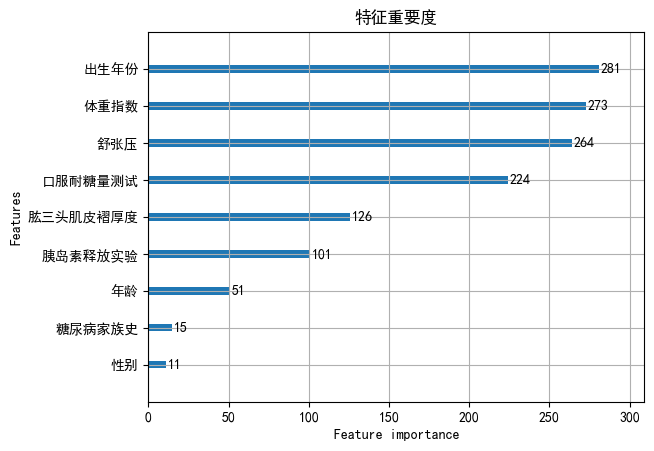

In [133]:
# 各特征重要度
lgbm.plot_importance(LGBMC,title = '特征重要度')
plt.rcParams['font.family'] = 'SimHei'  # 替换为你选择的字体
plt.savefig('特征重要度.jpg')
plt.show()

In [128]:
# 保存模型
joblib.dump(LGBMC,r'建模/LGBMC.pkl')

['建模/LGBMC.pkl']

### 5.2.2 模型应用

In [134]:
# 读取模型
LGBMC = joblib.load(r'建模/LGBMC.pkl')

In [135]:
predict_data = LGBMC.predict(test)
# 测试集路径
test_path = r'比赛测试集.csv'
testdf = pd.read_csv(test_path,encoding = 'gbk')
# 构建符合提交要求的submit
lgb_submit = pd.DataFrame({'uuid':testdf['编号'],'label':predict_data})
lgb_submit.to_csv(r'预测结果/lgb-submit7-4.csv',index = False,encoding = 'utf-8')
lgb_submit.head()

,uuid,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## 5.3 Catboost

In [175]:
# 导入catboost
import catboost
from sklearn.model_selection import KFold
from sklearn.model_selection import GroupKFold
# import warnings
# warnings.filterwarnings('ignore')

In [176]:
# 参数：trial,特征,标签,需要优化的超参数，交叉验证次数
def classification_objective(trial, x, y, fold_time):
    # 参数填充区域(此处根据需要修改)
    # 需要调优的参数
    params_grid = {# 等同‘n_estimators’
                  'iterations': trial.suggest_int('iterations', 10, 1000),  
                   # 学习率
                   'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                   # 等同max_depth，表示树模型的最大深度,最大值为16
                   'depth': trial.suggest_int('depth', 3, 16),
                   # L2正则化项的系数
                   'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0001, 3.0, log=True),
                   # 当再次随机选择特征时，每次分割选择时要使用的特征百分比
                   'rsm': trial.suggest_float('rsm', 0.2, 1.0),
                   # 等同max_bin,存储特征值的最大 bin 数
                   'border_count': trial.suggest_int('border_count', 10, 300),
                   # 用于计算叶子数的方法
                   'leaf_estimation_method': trial.suggest_categorical('leaf_estimation_method', ['Newton', 'Gradient', 'Simple']),
                   # 等同boosting
                   'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),
                   # 对象权重的抽样方法
                   'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
                   # 抽样方案
                   'sampling_unit': trial.suggest_categorical('sampling_unit', ['Object', 'Group']),
                   }
    # 交叉验证设置(回归用KFold，分类用StratifiedKFlod)
    # cv = StratifiedKFold(n_splits=fold_time, shuffle=True, random_state=2022)
    # cv = StratifiedKFold(n_splits=fold_time, shuffle=False)
    # 分组信息报错，使用其他分组方式
    # cv = KFold(n_splits=fold_time, shuffle=True, random_state=2022)
    # cv = KFold(n_splits=fold_time)
    # cv = GroupKFold(n_splits=fold_time)
    # 此处通过创建空数组用于记录预测分数
    # cv_scores = np.empty(fold_time)
    cv_scores = np.zeros(fold_time)
    # 训练集和测试集的划分
    # for idx, (train_idx, test_idx) in enumerate(cv.split(x, y)):
    #     x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    #     y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    idx = 0
    # for train_idx, test_idx in cv.split(x, y):
    #     x_train = x.iloc[train_idx]
    #     x_test = x.iloc[test_idx]
    #     y_train = y.iloc[train_idx]
    #     y_test = y.iloc[test_idx]
        # catboost的分类器/回归器初始化(此处根据需要修改)
        # model = catboost.CatBoostClassifier(loss_function='Logloss',  # 等同objective
        #                                     thread_count=-1,  # 等同n_jobs
        #                                     random_seed=2022,
        #                                     name='CatBoostClassifier',  # 在可视化工具中显示的实验名称
        #                                     task_type='CPU',  # 可选地包括CPU和GPU
        #                                     custom_metric='F1',  # 评估指标（eval_metric不好用）
        #                                     **params_grid)
        # # 填充训练数据进行测试
        # model.fit(
        #     x_train,
        #     y_train,
        #     eval_set=[(x_test, y_test)],
        #     early_stopping_rounds=100,
        #     verbose=False,  # 不显示训练过程
        #     metric_period=100,  # 设置指标计算频率
        #     use_best_model=True
        # )
        # # 获得模型的预测分数
        # pred_score = model.score(x_test, y_test)
        # # 将预测分数填入空数组中
        # cv_scores[idx] = pred_score
        # idx = idx + 1
    model = catboost.CatBoostClassifier(loss_function='Logloss',  # 等同objective
                                            thread_count=-1,  # 等同n_jobs
                                            random_seed=2022,
                                            name='CatBoostClassifier',  # 在可视化工具中显示的实验名称
                                            task_type='CPU',  # 可选地包括CPU和GPU
                                            # task_type='GPU',  # 可选地包括CPU和GPU
                                            custom_metric='F1',  # 评估指标（eval_metric不好用）
                                            **params_grid)
    # 填充训练数据进行测试
    model.fit(
        x,
        y,
        eval_set=[(x, y)],
        early_stopping_rounds=100,
        verbose=False,  # 不显示训练过程
        metric_period=100,  # 设置指标计算频率
        use_best_model=True
    )
    # 获得模型的预测分数
    pred_score = model.score(x, y)
    # 将预测分数填入空数组中
    cv_scores[idx] = pred_score
    # 返回预测平均值
    return np.mean(cv_scores)

In [181]:
print('正在运行中--------->')
# 设置完目标函数，开始调参
# direction:设置minimize最小化和maximize最大化
study = optuna.create_study(study_name = 'CatBoostClassifier',direction = 'maximize')
# 调用objective函数
func = lambda trial:classification_objective(trial,x,y,fold_time = 5)
# 运行的总 trial 数目
study.optimize(func,n_trials = 10)
print('运行成功~')

[I 2024-06-06 11:15:37,457] A new study created in memory with name: CatBoostClassifier


正在运行中--------->


[I 2024-06-06 12:07:45,592] Trial 0 finished with value: 0.19948717948717948 and parameters: {'iterations': 977, 'learning_rate': 0.27223663399841286, 'depth': 16, 'l2_leaf_reg': 0.11497593852751856, 'rsm': 0.4976050732837994, 'border_count': 167, 'leaf_estimation_method': 'Newton', 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS', 'sampling_unit': 'Object'}. Best is trial 0 with value: 0.19948717948717948.
[W 2024-06-06 12:07:45,653] Trial 1 failed with parameters: {'iterations': 966, 'learning_rate': 0.1592784672808203, 'depth': 15, 'l2_leaf_reg': 1.3299348395052275, 'rsm': 0.9841237014914972, 'border_count': 161, 'leaf_estimation_method': 'Simple', 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'sampling_unit': 'Group'} because of the following error: CatBoostError('C:/Go_Agent/pipelines/BuildMaster/catboost.git/catboost/private/libs/algo/tensor_search_helpers.cpp:498: No groups in dataset. Please disable sampling or use per object sampling').
Traceback (most recent ca

CatBoostError: C:/Go_Agent/pipelines/BuildMaster/catboost.git/catboost/private/libs/algo/tensor_search_helpers.cpp:498: No groups in dataset. Please disable sampling or use per object sampling

In [183]:
# 保存
filename = save_variable(study,'process_variable/catboost_study')
filename = save_variable(objective,'process_variable/classification_objective')
# filename = save_variable(model,'process_variable/model3')

In [184]:
# 读取
study = load_variavle('process_variable/catboost_study')
classification_objective = load_variavle('process_variable/classification_objective')
# model = load_variavle('process_variable/model4')

### 5.3.1 训练结果

In [182]:
print('最佳分数F1：')
print(f'{study.best_value}')
print('模型最佳属性：')
for key,value in study.best_params.items():
    print(f'{key}={value},')

最佳分数F1：
0.19948717948717948
模型最佳属性：
iterations=977,
learning_rate=0.27223663399841286,
depth=16,
l2_leaf_reg=0.11497593852751856,
rsm=0.4976050732837994,
border_count=167,
leaf_estimation_method=Newton,
boosting_type=Ordered,
bootstrap_type=MVS,
sampling_unit=Object,


In [185]:
%%time
# 划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)
# 将优化好的参数填入分类器中
CBC = catboost.CatBoostClassifier(loss_function='MultiClass',  # 等同objective
                                  thread_count=-1,  # 等同n_jobs
                                  random_seed=2022,
                                  name='CatBoostClassifier',  # 在可视化工具中显示的实验名称
                                  task_type='CPU',  # 可选地包括CPU和GPU
                                  custom_metric='F1',  # 评估指标
                                  iterations=175,
                                  learning_rate=0.129132881101942,
                                  depth=12,
                                  l2_leaf_reg=0.0006637625593489323,
                                  rsm=0.7732419704356603,
                                  border_count=244,
                                  leaf_estimation_method='Gradient',
                                  boosting_type='Plain',
                                  bootstrap_type='Bernoulli',
                                  sampling_unit='Object')
CBC.fit(x_train, y_train, verbose=False)

CPU times: total: 1min 56s
Wall time: 34.6 s


In [186]:
# 保存模型
joblib.dump(CBC,r'建模/CBC.pkl')

['建模/CBC.pkl']

### 5.3.2 模型应用

In [187]:
# 读取模型
CBC = joblib.load(r'建模/CBC.pkl')

In [188]:
predict_data = CBC.predict(test)
# catboost预测结果为二维数组，需要先转化为一维数组
predict_list = (list(np.array(predict_data).flatten()))
predict_list = [int(x) for x in predict_list]

In [189]:
predict_data = CBC.predict(test)
# 测试集路径
test_path = r'比赛测试集.csv'
testdf = pd.read_csv(test_path,encoding = 'gbk')
# 构建符合提交要求的submit
cbc_submit = pd.DataFrame({'uuid':testdf['编号'],'label':predict_list})
cbc_submit.to_csv(r'预测结果/cbc-submit7-5.csv',index = False,encoding = 'utf-8')
cbc_submit.head()

,uuid,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## 5.4 模型融合

In [190]:
%%time
# 导入投票分类器
from sklearn.ensemble import VotingClassifier
estimator_list = [('rfc',rfc_model),('lgb',LGBMC),['cat',CBC]]
final_model = VotingClassifier(estimator_list,voting = 'soft',n_jobs = -1)
final_model.fit(x_train,y_train)

CPU times: total: 391 ms
Wall time: 58 s


VotingClassifier(estimators=[('rfc',
                              RandomForestClassifier(max_depth=30,
                                                     min_samples_leaf=6,
                                                     n_estimators=470,
                                                     n_jobs=-1,
                                                     random_state=2022)),
                             ('lgb',
                              LGBMClassifier(bagging_fraction=0.9000000000000001,
                                             bagging_freq=1,
                                             feature_fraction=1.0,
                                             force_row_wise=True, lambda_l1=5,
                                             lambda_l2=5,
                                             learning_rate=0.2951856499133445,
                                             max_bin=265, max_depth=12,
                                             min_data_in_leaf=11,
                                             min_gain_to_split=0.0321897126179167,
                                             n_estimators=739, n_jobs=-1,
                                             num_leaves=98, objective='binary',
                                             verbose=-1)),
                             ['cat',
                              <catboost.core.CatBoostClassifier object at 0x00000203AFF96A00>]],
                 n_jobs=-1, voting='soft')

In [191]:
predict_data = final_model.predict(test)
# 测试集路径
test_path = r'比赛测试集.csv'
testdf = pd.read_csv(test_path,encoding = 'gbk')
# 构建符合提交要求的submit
voting_submit = pd.DataFrame({'uuid':testdf['编号'],'label':predict_data})
voting_submit.to_csv(r'预测结果/voting-submit7-5.csv',index = False,encoding = 'utf-8')
voting_submit.head()

,uuid,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
